# Multi-space conceptual entity test


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../src'))


In [2]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

from core import Scene
from processors import MotionConceptExtractor, VisualConceptExtractor
from structures import ConceptEntityMemory, ConceptMemory
from utils.concepts import load_traj_exports

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'text.usetex': True,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
})


## Load motion space


In [3]:
motion_export_dir = Path('trajectory_exports')
motion_manifest_path = motion_export_dir / 'manifest.csv'

motion_extractor = MotionConceptExtractor()
motion_points = load_traj_exports(
    motion_export_dir,
    manifest=motion_manifest_path,
    extractor=motion_extractor,
)
motion_memory = ConceptMemory.from_points(
    motion_extractor.space,
    motion_points,
)

motion_memory, motion_memory.vectors.shape


(<ConceptMemory with 4 points in R^90>, (4, 90))

## Load visual space


In [4]:
def select_object(scene, obj_id):
    if obj_id != 'auto':
        return scene[int(obj_id)]

    candidates = [
        obj for obj in scene
        if obj.num_snapshots > 0
    ]
    if not candidates:
        raise ValueError('No object with snapshots found')

    return max(
        candidates,
        key=lambda obj: (
            obj.num_snapshots,
            obj.num_poses,
            obj.last_seen.area,
        )
    )


visual_manifest_path = Path('visual_manifest.csv')
scene_dir = Path('test_scenes')

with visual_manifest_path.open(newline='') as f:
    visual_records = list(csv.DictReader(f))

visual_extractor = VisualConceptExtractor()
visual_points = []

for record in visual_records:
    scene = Scene.load(str(scene_dir / record['scene_file']))
    obj = select_object(scene, record['object_id'])

    visual_points.append(
        visual_extractor(
            obj.snapshots,
            label=record['label'],
            metadata={
                **record,
                'object_id': obj.obj_id,
                'num_snapshots': obj.num_snapshots,
            },
        )
    )

visual_memory = ConceptMemory.from_points(
    visual_extractor.space,
    visual_points,
)

visual_memory, visual_memory.vectors.shape


(<ConceptMemory with 5 points in R^54>, (5, 54))

## Space inventory


In [5]:
def point_key(point):
    return (
        point.metadata.get('scene_file'),
        point.metadata.get('object') or point.label,
        point.metadata.get('motion_label') or point.label,
    )


rows = {}

for point in motion_memory:
    key = point_key(point)
    rows.setdefault(key, {
        'scene_file': key[0],
        'object': key[1],
        'motion_label': key[2],
        'motion': 'missing',
        'visual': 'missing',
        'notes': '',
    })
    rows[key]['motion'] = point.metadata.get('usable_pose', 'yes')
    rows[key]['motion_point'] = point

for point in visual_memory:
    key = point_key(point)
    rows.setdefault(key, {
        'scene_file': key[0],
        'object': key[1],
        'motion_label': key[2],
        'motion': 'missing',
        'visual': 'missing',
        'notes': '',
    })
    rows[key]['visual'] = 'yes'
    rows[key]['visual_point'] = point
    rows[key]['notes'] = point.metadata.get('notes', '')

space_rows = sorted(
    rows.values(),
    key=lambda row: (
        row['object'],
        row['motion_label'],
        row['scene_file'] or '',
    )
)

header = f"{'object':<7} {'run':<18} {'motion':<8} {'visual':<8} notes"
print(header)
print('-' * len(header))
for row in space_rows:
    print(
        f"{row['object']:<7} "
        f"{row['motion_label']:<18} "
        f"{row['motion']:<8} "
        f"{row['visual']:<8} "
        f"{row['notes']}"
    )


object  run                motion   visual   notes
--------------------------------------------------
ball    roll               missing  yes      visual-only ball record; pose trajectory unavailable
boat    rotation           no       yes      boat visual record from weak rotation run
boat    translation        partial  yes      boat visual record from translation run
box     depth_translation  yes      yes      box visual record from successful depth-translation run
box     translation        yes      yes      box visual record from successful translation run


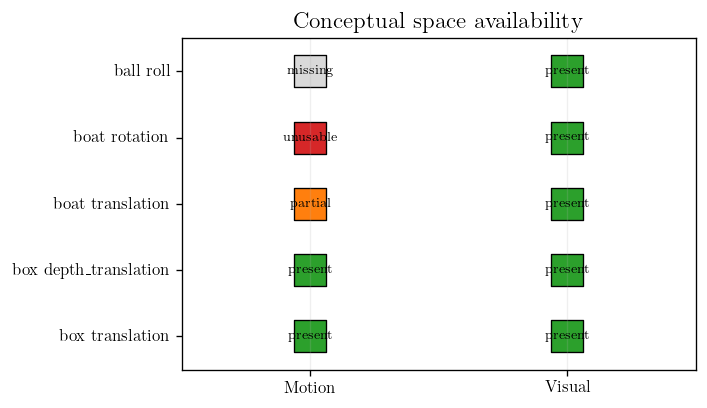

In [6]:
status_colors = {
    'yes': 'C2',
    'partial': 'C1',
    'no': 'C3',
    'missing': '0.85',
}
status_labels = {
    'yes': 'present',
    'partial': 'partial',
    'no': 'unusable',
    'missing': 'missing',
}

fig, ax = plt.subplots(figsize=(6, 3.5))

for y, row in enumerate(space_rows):
    for x, space in enumerate(['motion', 'visual']):
        status = row[space]
        ax.scatter(
            x, y,
            marker='s',
            s=360,
            color=status_colors.get(status, '0.85'),
            edgecolor='black',
            linewidth=0.8,
        )
        ax.text(
            x, y,
            status_labels.get(status, status),
            ha='center',
            va='center',
            fontsize=8,
        )

ax.set_xticks([0, 1], [r'Motion', r'Visual'])
ax.set_yticks(
    range(len(space_rows)),
    [f"{row['object']} {row['motion_label']}" for row in space_rows],
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(len(space_rows) - 0.5, -0.5)
ax.set_title('Conceptual space availability')
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.show()


## Multi-space entities


In [7]:
usable_motion_points = [
    point for point in motion_memory
    if point.metadata.get('usable_pose') == 'yes'
]
usable_motion_memory = ConceptMemory.from_points(
    motion_extractor.space,
    usable_motion_points,
)


def entity_key(space, point):
    return ':'.join([
        point.metadata.get('object') or str(point.label),
        point.metadata.get('motion_label') or str(point.label),
        point.metadata.get('scene_file') or '',
    ])


def entity_label(space, point):
    return point.metadata.get('object') or point.label


def entity_metadata(space, point):
    return {
        'scene_file': point.metadata.get('scene_file'),
        'object': point.metadata.get('object') or point.label,
        'motion_label': point.metadata.get('motion_label') or point.label,
        f'{space}_status': (
            point.metadata.get('usable_pose')
            if space == 'motion'
            else 'yes'
        ),
        'notes': point.metadata.get('notes', ''),
    }


entity_memory = ConceptEntityMemory.from_space_memories(
    {
        'motion': usable_motion_memory,
        'visual': visual_memory,
    },
    key_fn=entity_key,
    label_fn=entity_label,
    metadata_fn=entity_metadata,
)

for entity in entity_memory:
    print(
        f"{entity.label:<7} "
        f"{entity.metadata['motion_label']:<18} "
        f"spaces={entity.available_spaces}"
    )


ball    roll               spaces=['visual']
boat    rotation           spaces=['visual']
boat    translation        spaces=['visual']
box     depth_translation  spaces=['motion', 'visual']
box     translation        spaces=['motion', 'visual']


## Shared-space distances


In [8]:
space_weights = {
    'motion': 1.0,
    'visual': 1.0,
}

for query in entity_memory:
    print(f"{query.label} {query.metadata['motion_label']}")

    for candidate, dist in entity_memory.nearest(
            query,
            k=len(entity_memory),
            space_weights=space_weights,
    ):
        if candidate is query:
            continue

        shared = ', '.join(query.shared_spaces(candidate))
        print(
            f"  to {candidate.label:<5} "
            f"{candidate.metadata['motion_label']:<18} "
            f"d={dist:.3f} "
            f"spaces={shared}"
        )


ball roll
  to box   depth_translation  d=4.937 spaces=visual
  to boat  translation        d=5.239 spaces=visual
  to boat  rotation           d=8.920 spaces=visual
  to box   translation        d=18.240 spaces=visual
boat rotation
  to boat  translation        d=7.958 spaces=visual
  to ball  roll               d=8.920 spaces=visual
  to box   depth_translation  d=11.555 spaces=visual
  to box   translation        d=21.431 spaces=visual
boat translation
  to ball  roll               d=5.239 spaces=visual
  to box   depth_translation  d=7.357 spaces=visual
  to boat  rotation           d=7.958 spaces=visual
  to box   translation        d=19.297 spaces=visual
box depth_translation
  to ball  roll               d=4.937 spaces=visual
  to boat  translation        d=7.357 spaces=visual
  to box   translation        d=9.310 spaces=motion, visual
  to boat  rotation           d=11.555 spaces=visual
box translation
  to box   depth_translation  d=9.310 spaces=motion, visual
  to ball  roll 

## Strict joint distances


In [ ]:
for query in entity_memory:
    print(f"{query.label} {query.metadata['motion_label']}")

    neighbors = entity_memory.nearest(
        query,
        k=len(entity_memory),
        space_weights=space_weights,
        required_spaces=['motion', 'visual'],
    )

    printed = False
    for candidate, dist in neighbors:
        if candidate is query:
            continue

        printed = True
        print(
            f"  to {candidate.label:<5} "
            f"{candidate.metadata['motion_label']:<18} "
            f"d={dist:.3f} "
            f"spaces={', '.join(query.shared_spaces(candidate))}"
        )

    if not printed:
        print('  no comparable entity with both motion and visual spaces')


## Space prototypes


In [9]:
motion_prototypes = motion_memory.prototypes()
visual_prototypes = visual_memory.prototypes()

print('Motion prototypes')
for label, proto in motion_prototypes.items():
    print(f'  {label:<18} support={proto.support}')

print('\nVisual prototypes')
for label, proto in visual_prototypes.items():
    print(f'  {label:<18} support={proto.support}')


Motion prototypes
  translation        support=2
  depth_translation  support=1
  rotation           support=1

Visual prototypes
  box                support=2
  boat               support=2
  ball               support=1


In [10]:
def print_prototype_distances(memory, prototypes, title):
    print(title)
    for point in memory:
        obj = point.metadata.get('object') or point.label
        run = point.metadata.get('motion_label') or point.label
        print(f'{obj} {run}')

        for label, proto in prototypes.items():
            dist = memory.space.distance(point, proto)
            print(f'  to {label:<18}: {dist:.3f}')


print_prototype_distances(
    motion_memory,
    motion_prototypes,
    'Motion-domain distances',
)
print()
print_prototype_distances(
    visual_memory,
    visual_prototypes,
    'Visual-domain distances',
)


Motion-domain distances
box translation
  to translation       : 0.812
  to depth_translation : 1.065
  to rotation          : 1.741
box depth_translation
  to translation       : 0.812
  to depth_translation : 0.000
  to rotation          : 1.433
boat translation
  to translation       : 0.812
  to depth_translation : 1.226
  to rotation          : 1.885
boat rotation
  to translation       : 1.623
  to depth_translation : 1.433
  to rotation          : 0.000

Visual-domain distances
box translation
  to box               : 8.778
  to boat              : 20.000
  to ball              : 18.240
box depth_translation
  to box               : 8.778
  to boat              : 8.831
  to ball              : 4.937
boat translation
  to box               : 11.670
  to boat              : 3.979
  to ball              : 5.239
boat rotation
  to box               : 14.810
  to boat              : 3.979
  to ball              : 8.920
ball roll
  to box               : 10.074
  to boat              